### Job shop scheduling problem

The job shop scheduling problem consists of minimizing the total time required to complete a production plan involving a given set of jobs and machines. This quantity is known as the **makespan**. The problem is of the min-max type, since it effectively minimizes the maximum completion time of the production schedule.

* $J$: Set of jobs
* $M$: Set of machines
* $O_j$: Set of operations of job $j \in J$, in sequential order
* $p_{j,o}$: Processing time of operation $o$ of job $j$
* $m_{j,o}$: Machine assigned to operation $o$ of job $j$
* $Big_M$: A sufficiently large constant

* $S_{j,o} \geq 0$: Start time of operation $o$ of job $j$
* $C_{\max} \geq 0$: Total completion time (makespan)
* $y_{(j,o),(j',o')} \in \{0,1\}$: Binary variable indicating the execution order between two operations that require the same machine

$$
\begin{aligned}
\min \quad & C_{\max} \\
\textbf{s.t.} \quad
& S_{j,o+1} \geq S_{j,o} + p_{j,o} && \forall j \in J,\ o < |O_j| \\
& S_{j,o} + p_{j,o} \leq S_{j',o'} + Big_M(1 - y_{(j,o),(j',o')}) \\
& S_{j',o'} + p_{j',o'} \leq S_{j,o} + Big_M y_{(j,o),(j',o')} \\
& \forall (j,o),(j',o'): m_{j,o} = m_{j',o'},\ (j,o) \neq (j',o') \\
& C_{\max} \geq S_{j,|O_j|-1} + p_{j,|O_j|-1} && \forall j \in J
\end{aligned}
$$


In [1]:
%pip install gurobipy
from gurobipy import Model, GRB, quicksum

In [2]:
# Data
jobs = {
    "J1": [("M1", 3), ("M2", 2), ("M3", 2)],
    "J2": [("M2", 2), ("M1", 1), ("M3", 4)],
    "J3": [("M3", 4), ("M1", 3), ("M2", 1)]
}
machines = {"M1", "M2", "M3"}

# Sets
operations = []  # (job, operation number, machine)
for j, ops in jobs.items():
    for i, (m, d) in enumerate(ops):
        operations.append((j, i, m))

# Model
model = Model("job_shop")

# Operation start time variables
start = model.addVars(operations, name="start", vtype=GRB.CONTINUOUS)

# Makespan variable
Cmax = model.addVar(name="Cmax", vtype=GRB.CONTINUOUS)

# Constraint: precedence of operations within the same job
for j, ops in jobs.items():
    for i in range(len(ops) - 1):
        m1, d1 = ops[i]
        m2, d2 = ops[i + 1]
        model.addConstr(start[j, i + 1, m2] >= start[j, i, m1] + d1)

# Constraint: each machine can process only one operation at a time
for m in machines:
    tasks_on_m = [(j, i, mach) for (j, i, mach) in operations if mach == m]
    for t1 in tasks_on_m:
        for t2 in tasks_on_m:
            if t1 < t2:
                j1, i1, _ = t1
                j2, i2, _ = t2
                d1 = jobs[j1][i1][1]
                d2 = jobs[j2][i2][1]
                y = model.addVar(vtype=GRB.BINARY)
                model.addConstr(start[t1] + d1 <= start[t2] + (1 - y) * 1000)
                model.addConstr(start[t2] + d2 <= start[t1] + y * 1000)

# Constraint: makespan must be greater than or equal to the completion time of each job
for j, ops in jobs.items():
    m, d = ops[-1]
    model.addConstr(Cmax >= start[j, len(ops) - 1, m] + d)

# Objective
model.setObjective(Cmax, GRB.MINIMIZE)

# Solve
model.optimize()

# Results
for v in model.getVars():
    if "start" in v.varName:
        print(f"{v.varName} = {v.x:.1f}")
print(f"Makespan = {Cmax.x:.1f}")


Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 27 rows, 19 columns and 72 nonzeros (Min)
Model fingerprint: 0x97cfa9a5
Model has 1 linear objective coefficients
Variable types: 10 continuous, 9 integer (9 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]

Presolve removed 1 rows and 0 columns
Presolve time: 0.00s
Presolved: 26 rows, 19 columns, 72 nonzeros
Variable types: 10 continuous, 9 integer (9 binary)
Found heuristic solution: objective 18.0000000

Root relaxation: objective 8.000000e+00, 7 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds

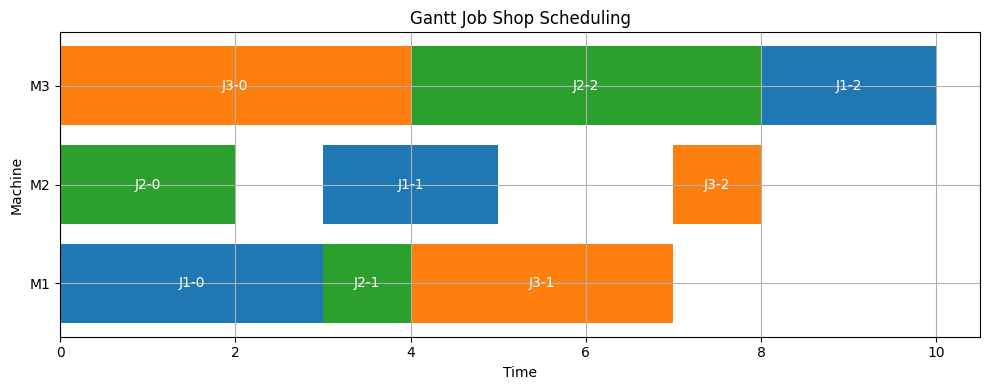

In [3]:
import matplotlib.pyplot as plt
# Make data available for Gantt diagram
gantt_data = []
for (j, i, m) in operations:
    s = start[j, i, m].X
    d = jobs[j][i][1]
    gantt_data.append((m, s, d, j, i))

# Plot Gantt diagram
fig, ax = plt.subplots(figsize=(10, 4))
colors = {'J1': 'tab:blue', 'J2': 'tab:green', 'J3': 'tab:orange'}
for m_idx, (m, s, d, j, i) in enumerate(sorted(gantt_data, key=lambda x: x[0])):
    ax.barh(m, d, left=s, color=colors[j])
    ax.text(s + d/2, m, f"{j}-{i}", ha='center', va='center', color='white')

ax.set_xlabel("Time")
ax.set_ylabel("Machine")
ax.set_title("Gantt Job Shop Scheduling")
ax.grid(True)
plt.tight_layout()
plt.show()

In [4]:
import random

# Configurable parameters
num_jobs = 10
num_machines = 6
min_time = 1
max_time = 15

# Create machines
machines = [f"M{i+1}" for i in range(num_machines)]

# Create random jobs (each job goes through all machines in random order)
jobs = {}
for j in range(1, num_jobs + 1):
    job_name = f"J{j}"
    machine_sequence = random.sample(machines, len(machines))
    job_ops = [(m, random.randint(min_time, max_time)) for m in machine_sequence]
    jobs[job_name] = job_ops

In [5]:
# Create model
model = Model("random_job_shop")

# Sets
operations = [(j, i, m) for j, ops in jobs.items() for i, (m, _) in enumerate(ops)]

# Variables
start = model.addVars(operations, name="start", vtype=GRB.CONTINUOUS)
Cmax = model.addVar(name="Cmax", vtype=GRB.CONTINUOUS)

# Precedence constraints
for j, ops in jobs.items():
    for i in range(len(ops) - 1):
        m1, d1 = ops[i]
        m2, _ = ops[i + 1]
        model.addConstr(start[j, i + 1, m2] >= start[j, i, m1] + d1)

# Non-overlap constraints on the same machine
for m in machines:
    tasks_on_m = [(j, i, mach) for (j, i, mach) in operations if mach == m]
    for idx1, t1 in enumerate(tasks_on_m):
        for idx2 in range(idx1 + 1, len(tasks_on_m)):
            t2 = tasks_on_m[idx2]
            j1, i1, _ = t1
            j2, i2, _ = t2
            d1 = jobs[j1][i1][1]
            d2 = jobs[j2][i2][1]
            y = model.addVar(vtype=GRB.BINARY)
            model.addConstr(start[t1] + d1 <= start[t2] + (1 - y) * 1000)
            model.addConstr(start[t2] + d2 <= start[t1] + y * 1000)

# Makespan constraints
for j, ops in jobs.items():
    m, d = ops[-1]
    model.addConstr(Cmax >= start[j, len(ops) - 1, m] + d)

# Objective
model.setObjective(Cmax, GRB.MINIMIZE)

# Solve
model.optimize()

# Results
print("Generated instance:")
for j, ops in jobs.items():
    print(f"{j}: {ops}")

print("\nResults:")
for v in model.getVars():
    if "start" in v.varName:
        print(f"{v.varName} = {v.x:.1f}")

print(f"Makespan = {Cmax.x:.1f}")

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 600 rows, 331 columns and 1740 nonzeros (Min)
Model fingerprint: 0x9a7388d7
Model has 1 linear objective coefficients
Variable types: 61 continuous, 270 integer (270 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]

Presolve time: 0.01s
Presolved: 600 rows, 331 columns, 1740 nonzeros
Variable types: 61 continuous, 270 integer (270 binary)
Found heuristic solution: objective 314.0000000

Root relaxation: objective 6.400000e+01, 180 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node 

/tmp/ipykernel_4175/4175909938.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", num_jobs)


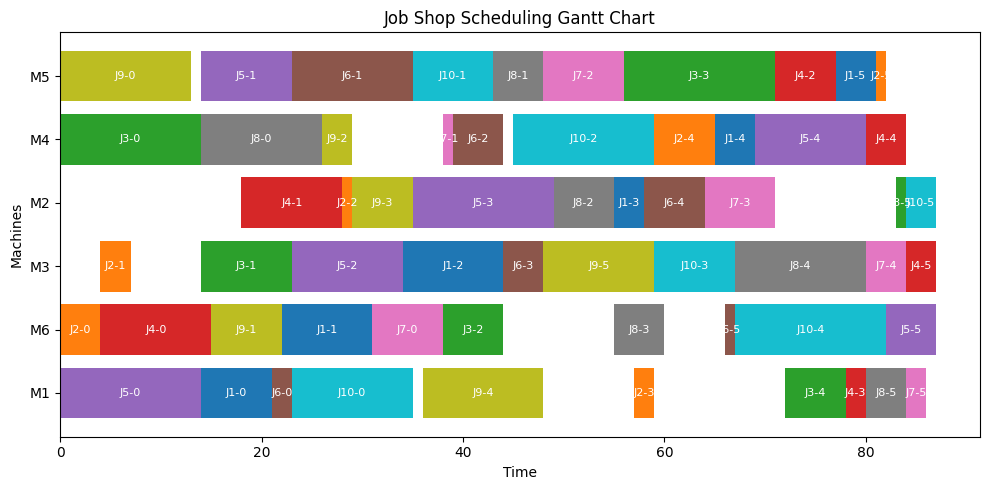

In [6]:
# Data for Gantt chart
gantt_data = []
for (j, i, m) in operations:
    s = start[j, i, m].X
    d = jobs[j][i][1]
    gantt_data.append((m, s, d, j, i))

# Draw Gantt chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.get_cmap("tab10", num_jobs)
for m, s, d, j, i in gantt_data:
    ax.barh(m, d, left=s, color=colors(int(j[1:]) - 1))
    ax.text(s + d / 2, m, f"{j}-{i}", ha='center', va='center', color='white', fontsize=8)

ax.set_xlabel("Time")
ax.set_ylabel("Machines")
ax.set_title("Job Shop Scheduling Gantt Chart")
# ax.grid(True)
plt.tight_layout()
plt.show()